# 📈 Store Sales Forecasting — with Lag Features

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier


## 2. Load Data

In [2]:
train    = pd.read_csv('train.csv', parse_dates=['date'])
test     = pd.read_csv('test.csv',  parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
stores   = pd.read_csv('stores.csv')

train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## 3. Exploratory Data Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_4608\1193572823.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('day_of_week')['sales'].mean().plot(kind='bar', ax=axes[0], title='Avg Sales by Day of Week', color='steelblue')


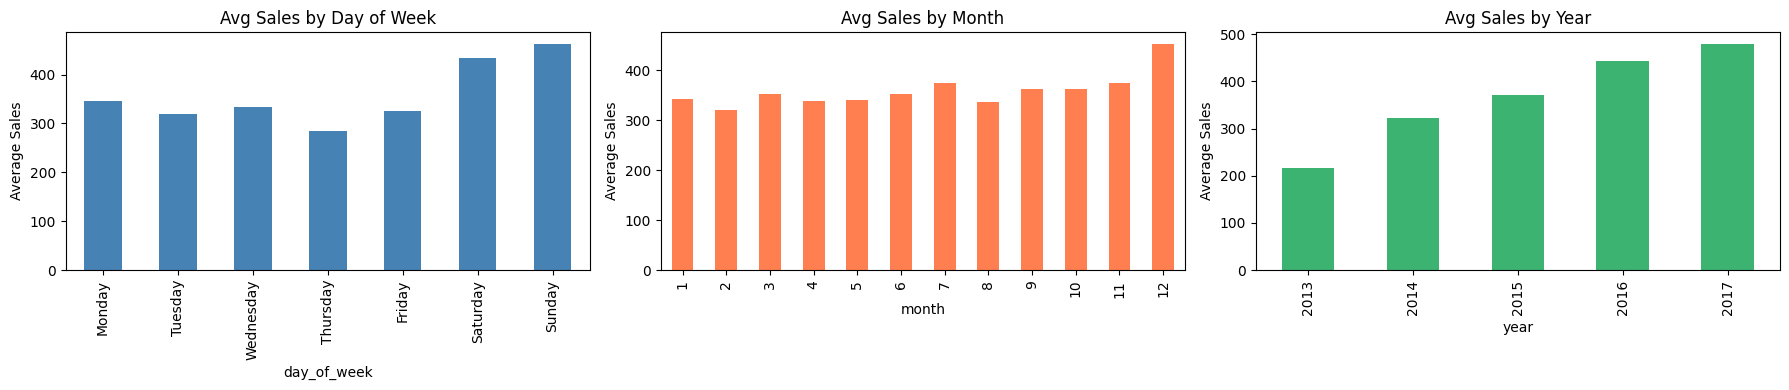

In [3]:
train['day_of_week'] = train['date'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
train['day_of_week'] = pd.Categorical(train['day_of_week'], ordered=True, categories=order)
train['year']  = train['date'].dt.year
train['month'] = train['date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
train.groupby('day_of_week')['sales'].mean().plot(kind='bar', ax=axes[0], title='Avg Sales by Day of Week', color='steelblue')
train.groupby('month')['sales'].mean().plot(kind='bar', ax=axes[1], title='Avg Sales by Month', color='coral')
train.groupby('year')['sales'].mean().plot(kind='bar', ax=axes[2], title='Avg Sales by Year', color='mediumseagreen')
for ax in axes:
    ax.set_ylabel('Average Sales')
plt.tight_layout()
plt.show()


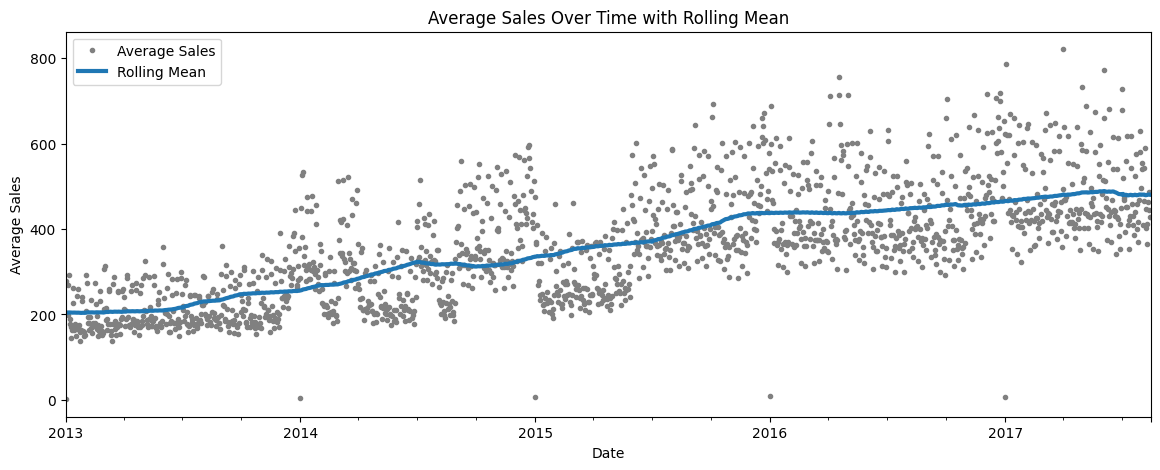

In [4]:
avg_sales = train.groupby('date').agg({'sales': 'mean'}).reset_index()
avg_sales = avg_sales.set_index('date').to_period('D')

rolling = avg_sales['sales'].rolling(window=365, center=True, min_periods=183).mean()
fig, ax = plt.subplots(figsize=(14, 5))
avg_sales.plot(style='.', color='0.5', ax=ax)
rolling.plot(ax=ax, linewidth=3)
ax.set_title('Average Sales Over Time with Rolling Mean')
ax.set_xlabel('Date')
ax.set_ylabel('Average Sales')
ax.legend(['Average Sales', 'Rolling Mean'])
plt.show()


## 4. Periodogram — Identify Seasonal Frequencies

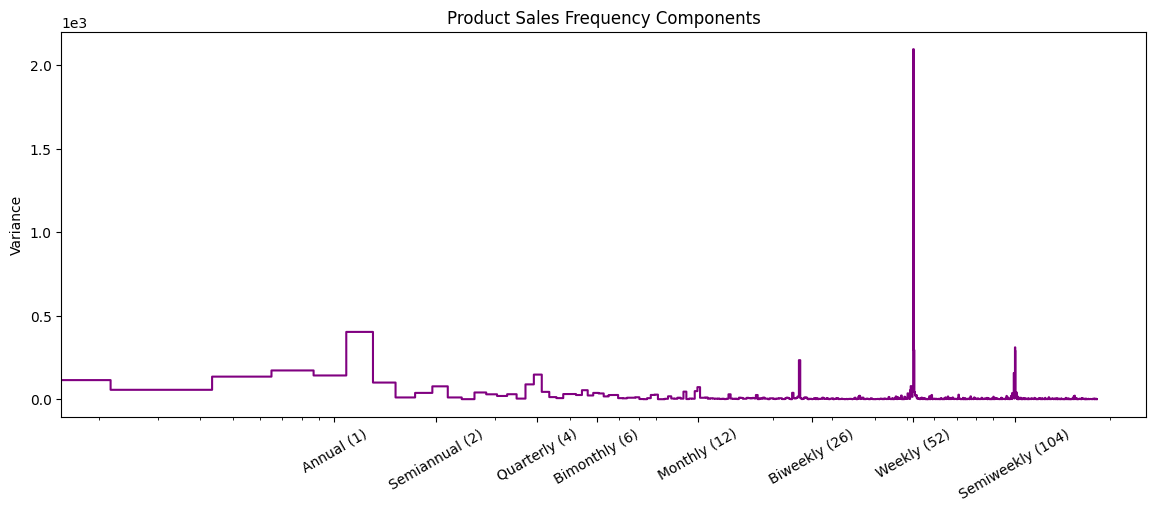

In [5]:
def plot_periodogram(ts, detrend='linear', ax=None, color='purple'):
    from scipy.signal import periodogram
    fs = 365.25
    freqs, spectrum = periodogram(ts, fs=fs, detrend=detrend, window='boxcar', scaling='spectrum')
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqs, spectrum, color=color)
    ax.set_xscale('log')
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        ['Annual (1)', 'Semiannual (2)', 'Quarterly (4)', 'Bimonthly (6)',
         'Monthly (12)', 'Biweekly (26)', 'Weekly (52)', 'Semiweekly (104)'],
        rotation=30
    )
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_ylabel('Variance')
    ax.set_title('Periodogram')
    return ax

y_avg = avg_sales['sales']
fig, ax = plt.subplots(figsize=(14, 5))
plot_periodogram(y_avg, ax=ax)
ax.set_title('Product Sales Frequency Components')
plt.show()


## 5. Holiday Feature Engineering

In [6]:
holidays = holidays.set_index('date').to_period('D')
holidays = holidays[(holidays['locale'].isin(['National', 'Regional'])) & (~holidays['transferred'])]

holi       = pd.get_dummies(holidays['description'], prefix='holiday')
X_holidays = holi.groupby(level=0).max()

print(f"Total holiday features: {X_holidays.shape[1]}")
X_holidays.head()


Total holiday features: 76


,holiday_Batalla de Pichincha,holiday_Black Friday,holiday_Carnaval,holiday_Cyber Monday,holiday_Dia de Difuntos,holiday_Dia de la Madre,holiday_Dia de la Madre-1,holiday_Dia del Trabajo,holiday_Inauguracion Mundial de futbol Brasil,holiday_Independencia de Cuenca,...,holiday_Terremoto Manabi+5,holiday_Terremoto Manabi+6,holiday_Terremoto Manabi+7,holiday_Terremoto Manabi+8,holiday_Terremoto Manabi+9,holiday_Traslado Batalla de Pichincha,holiday_Traslado Independencia de Guayaquil,holiday_Traslado Primer Grito de Independencia,holiday_Traslado Primer dia del ano,holiday_Viernes Santo
date,,,,,,,,,,,,,,,,,,,,,
2012-04-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2012-06-25,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2012-08-10,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2012-10-12,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2012-11-02,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 6. Simple Average-Sales Model (with Lag Features)

> **What are lag features?**  
> A lag-7 feature at day *t* = the actual sales value at day *t−7*.  
> This lets the model learn autocorrelation — that last week's sales predicts this week's sales.  
> We must drop the first 28 rows because those dates have no 28-day history yet.

In [7]:
fourier = CalendarFourier(freq='YE', order=10)
dp_avg = DeterministicProcess(
    index=avg_sales.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True
)
X_avg = dp_avg.in_sample()

# Calendar features
X_avg['is_weekend']  = (X_avg.index.day_of_week >= 5).astype(int)
X_avg['week_of_year'] = X_avg.index.weekofyear.astype(int)

# Holiday features
X_avg = X_avg.join(X_holidays, on='date').fillna(0.0)

# ── NEW: Lag Features ─────────────────────────────────────────────────────────
y_avg = avg_sales['sales']

X_avg['lag_7']  = y_avg.shift(7).values   # same day, previous week
X_avg['lag_28'] = y_avg.shift(28).values  # same day ~4 weeks ago

# Drop first 28 rows where lags are NaN
valid_mask    = X_avg[['lag_7', 'lag_28']].notna().all(axis=1)
X_avg_train   = X_avg[valid_mask]
y_avg_train   = y_avg[valid_mask]

print(f"Training rows after dropping NaN lags: {len(X_avg_train)}  (dropped {valid_mask.sum()==False} rows)")
print(f"Total features: {X_avg_train.shape[1]}")
X_avg_train[['lag_7', 'lag_28']].describe()


Training rows after dropping NaN lags: 1656  (dropped False rows)
Total features: 108


,lag_7,lag_28
count,1656.000000,1656.000000
mean,359.535638,355.883067
std,131.056937,131.517584
min,4.827197,1.409438
25%,250.487342,245.754308
50%,356.447525,351.771550
75%,441.819737,438.313590
max,821.034771,821.034771


In-sample RMSE (with lags): 51.2922


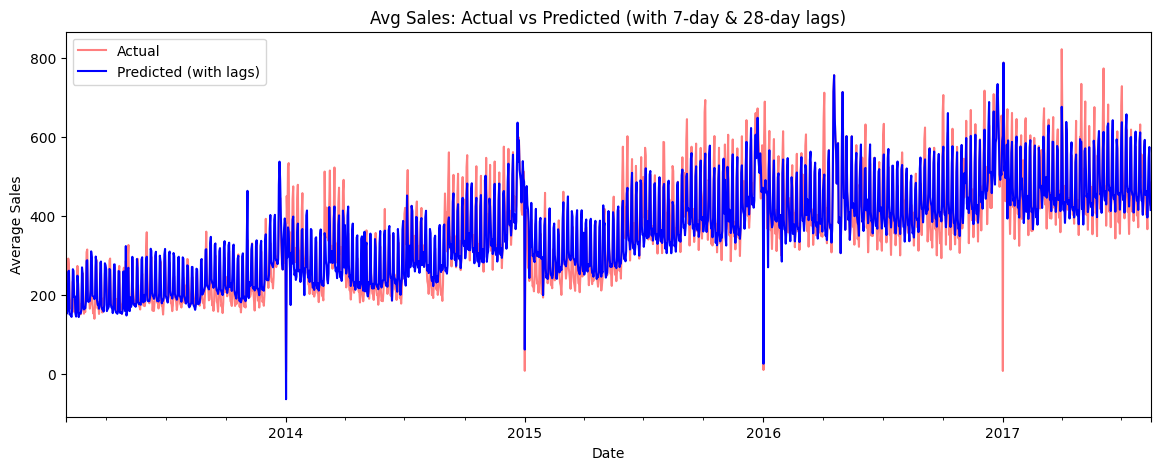

In [8]:
lr_avg = LinearRegression(fit_intercept=False)
lr_avg.fit(X_avg_train, y_avg_train)
y_avg_pred = pd.Series(lr_avg.predict(X_avg_train), index=X_avg_train.index)

# In-sample RMSE
rmse_avg = np.sqrt(mean_squared_error(y_avg_train, y_avg_pred))
print(f"In-sample RMSE (with lags): {rmse_avg:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
y_avg_train.plot(ax=ax, label='Actual', color='red', alpha=0.5)
y_avg_pred.plot(ax=ax, label='Predicted (with lags)', color='blue')
ax.set_title('Avg Sales: Actual vs Predicted (with 7-day & 28-day lags)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Sales')
ax.legend()
plt.show()


### 6a. Forecast Future 200 Days

> For future dates, we don't have actual sales to use as lags.  
> We use the **last 28 days of training data** as the lag seed, then roll forward iteratively.

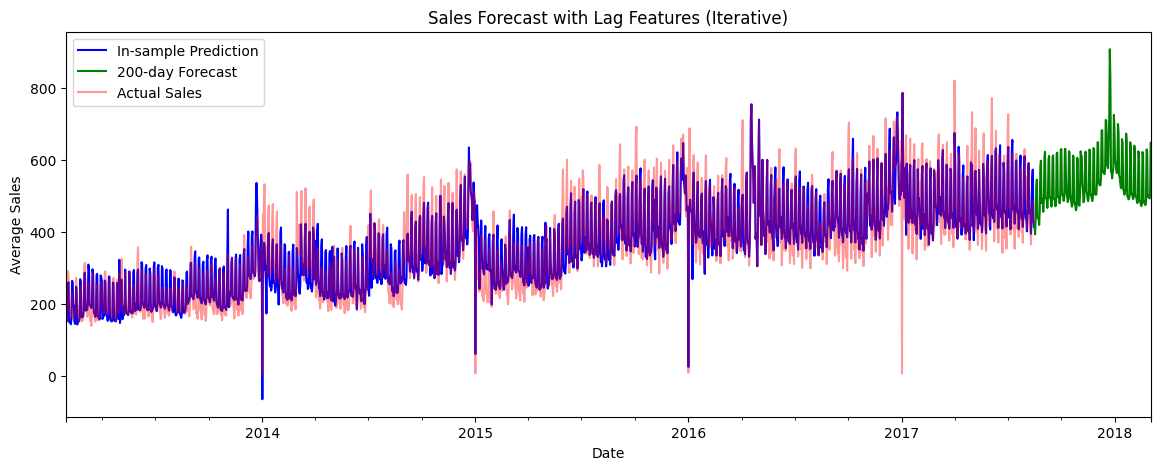

In [9]:
X_fore = dp_avg.out_of_sample(200)

# Time features
X_fore['is_weekend'] = (X_fore.index.dayofweek >= 5).astype(int)

X_fore['week_of_year'] = X_fore.index.week.astype(int)

# Join holidays (index-based)
X_fore = X_fore.join(X_holidays).fillna(0.0)

# Seed lag buffer
lag_buffer = list(y_avg.values[-28:])
forecast_values = []

for i in range(len(X_fore)):
    row = X_fore.iloc[[i]].copy()

    row['lag_7'] = lag_buffer[-7]
    row['lag_28'] = lag_buffer[-28]

    pred = lr_avg.predict(row)[0]

    forecast_values.append(pred)
    lag_buffer.append(pred)

# Forecast series
y_fore_avg = pd.Series(forecast_values, index=X_fore.index)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

y_avg_pred.plot(ax=ax, label='In-sample Prediction', color='blue')
y_fore_avg.plot(ax=ax, label='200-day Forecast', color='green')
y_avg_train.plot(ax=ax, label='Actual Sales', color='red', alpha=0.4)

ax.set_title('Sales Forecast with Lag Features (Iterative)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Sales')
ax.legend()

plt.show()

## 7. Full Store-Level Model (with Lag Features)

> The store-level model predicts sales for each of 54 stores × 33 product families simultaneously (multi-output regression).  
> Here we use the **global mean lag** (average across all stores and families) as a shared context feature. This is a valid approximation and is a standard approach before moving to per-series BoostedHybrid models.

In [10]:
store_sales = pd.read_csv(
    'train.csv',
    usecols=['store_nbr', 'family', 'date', 'sales'],
    parse_dates=['date'],
    infer_datetime_format=True,
)
store_sales['date'] = store_sales.date.dt.to_period('D')
store_sales = store_sales.set_index(['store_nbr', 'family', 'date']).sort_index()

# Wide format: rows=date, columns=(sales, store_nbr, family)
y = store_sales.unstack(['store_nbr', 'family'])

fourier  = CalendarFourier(freq='M', order=4)
fourier2 = CalendarFourier(freq='A', order=10)
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier, fourier2],
    drop=True,
)
X = dp.in_sample()
X['is_weekend'] = (X.index.dayofweek >= 5).astype(int)
X['NewYear']    = (X.index.dayofyear == 1).astype(int)
X = X.join(X_holidays, on='date').fillna(0.0)

# ── NEW: Global Mean Lag Features ────────────────────────────────────────────
mean_sales_per_day = y.mean(axis=1)   # average sales across all store/family series

X['lag_7_mean']  = mean_sales_per_day.shift(7).values
X['lag_28_mean'] = mean_sales_per_day.shift(28).values

# Drop first 28 rows where lags are NaN
valid_mask = X[['lag_7_mean', 'lag_28_mean']].notna().all(axis=1)
X_train = X[valid_mask]
y_train = y[valid_mask]

print(f"Training shape after lag NaN drop: X={X_train.shape}, y={y_train.shape}")
print(f"New lag features: lag_7_mean, lag_28_mean")
X_train[['lag_7_mean', 'lag_28_mean']].describe()


C:\Users\user\AppData\Local\Temp\ipykernel_4608\2626391535.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  store_sales = pd.read_csv(


Training shape after lag NaN drop: X=(1656, 116), y=(1656, 1782)
New lag features: lag_7_mean, lag_28_mean


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


,lag_7_mean,lag_28_mean
count,1656.000000,1656.000000
mean,359.535638,355.883067
std,131.056937,131.517584
min,4.827197,1.409438
25%,250.487342,245.754308
50%,356.447525,351.771550
75%,441.819737,438.313590
max,821.034771,821.034771


In [11]:
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = pd.DataFrame(
    model.predict(X_train),
    index=X_train.index,
    columns=y_train.columns
).clip(lower=0)

# ── Evaluation ────────────────────────────────────────────────────────────────
overall_rmse = np.sqrt(mean_squared_error(
    y_train.stack([1, 2], future_stack=True).dropna(),
    y_pred.stack([1, 2], future_stack=True).dropna()
))

# RMSLE — matches Kaggle competition metric
def rmsle(y_true, y_pred):
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

rmsle_score = rmsle(
    y_train.stack([1, 2], future_stack=True).dropna().values,
    y_pred.stack([1, 2], future_stack=True).dropna().values
)

print(f"Overall RMSE  : {overall_rmse:.4f}")
print(f"Overall RMSLE : {rmsle_score:.4f}  ← Kaggle competition metric")


Overall RMSE  : 277.8008
Overall RMSLE : 1.0775  ← Kaggle competition metric


### 7a. Forecast Test Period

In [12]:
df_test = pd.read_csv(
    'test.csv',
    dtype={'store_nbr': 'category', 'family': 'category', 'onpromotion': 'uint32'},
    parse_dates=['date'],
    infer_datetime_format=True,
)
df_test['date'] = df_test.date.dt.to_period('D')
df_test = df_test.set_index(['store_nbr', 'family', 'date']).sort_index()

X_test = dp.out_of_sample(steps=16)
X_test.index.name = 'date'
X_test['is_weekend'] = (X_test.index.dayofweek >= 5).astype(int)
X_test['NewYear']    = (X_test.index.dayofyear == 1).astype(int)
X_test = X_test.join(X_holidays, on='date').fillna(0.0)

# ── Propagate lag features into forecast period ────────────────────────────────
# Seed: last 28 days of mean sales from training
lag_seed = mean_sales_per_day.values[-28:].tolist()
mean_pred_buffer = lag_seed.copy()

# We'll do a row-by-row forecast to maintain rolling lags
forecast_rows = []

for i in range(len(X_test)):
    row = X_test.iloc[[i]].copy()
    row['lag_7_mean']  = mean_pred_buffer[-7]
    row['lag_28_mean'] = mean_pred_buffer[-28]

    pred_row = pd.DataFrame(
        model.predict(row),
        index=row.index,
        columns=y.columns
    ).clip(lower=0)
    
    forecast_rows.append(pred_row)
    mean_pred_buffer.append(float(pred_row.values.mean()))  # roll the buffer

y_fore = pd.concat(forecast_rows)

print(f"Forecast shape: {y_fore.shape}")
y_fore.head()


C:\Users\user\AppData\Local\Temp\ipykernel_4608\3926224091.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_test = pd.read_csv(
C:\Users\user\AppData\Local\Temp\ipykernel_4608\3926224091.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.join(X_holidays, on='date').fillna(0.0)


Forecast shape: (16, 1782)


sales                                                          \
store_nbr          1                                                            
family     AUTOMOTIVE BABY CARE    BEAUTY    BEVERAGES     BOOKS BREAD/BAKERY   
date                                                                            
2017-08-16   4.620807       0.0  3.619117  2296.346862  0.412665   438.532004   
2017-08-17   4.518509       0.0  3.631655  2223.221564  0.399167   434.182384   
2017-08-18   4.855173       0.0  3.576303  2433.000999  0.299278   445.173516   
2017-08-19   3.417876       0.0  2.828349  1854.512796  0.285740   334.020448   
2017-08-20   3.582800       0.0  2.652648  1815.321659  0.304075   327.884537   

                                                            ...            \
store_nbr                                                   ...        54   
family     CELEBRATION    CLEANING       DAIRY        DELI  ... MAGAZINES   
date                                                        ...             
2017-08-16   15.738644  732.931909  798.851867  148.154977  ...  0.832403   
2017-08-17   22.587743  694.884662  804.926739  139.146299  ...  0.869838   
2017-08-18   20.450254  740.851194  829.116040  149.933285  ...  1.165878   
2017-08-19    9.991373  465.015269  676.036599  110.105648  ...  1.495579   
2017-08-20    9.186382  464.750426  641.843193  109.639862  ...  1.562685   

                                                                          \
store_nbr                                                                  
family          MEATS PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS   
date                                                                       
2017-08-16  61.685655    173.378686     0.164412                3.273956   
2017-08-17  63.171669    164.886284     0.062333                3.020522   
2017-08-18  59.113227    167.501466     0.130680                4.002529   
2017-08-19  69.781232    237.037255     0.104143                4.038905   
2017-08-20  68.015124    248.056838     0.192115                4.464149   

                                                                             \
store_nbr                                                                     
family        POULTRY PREPARED FOODS     PRODUCE SCHOOL AND OFFICE SUPPLIES   
date                                                                          
2017-08-16  62.912371      84.809434  677.279554                   1.113618   
2017-08-17  61.878834      85.526367  564.777150                   0.795801   
2017-08-18  58.942444      79.497811  709.550603                   1.070285   
2017-08-19  78.082214      88.820784  599.972528                   1.103261   
2017-08-20  70.452396      89.412871  689.075375                   1.406025   

                      
store_nbr             
family       SEAFOOD  
date                  
2017-08-16  2.283594  
2017-08-17  1.660702  
2017-08-18  1.738258  
2017-08-19  1.544824  
2017-08-20  1.246224  

[5 rows x 1782 columns]

## 8. Visualize Results

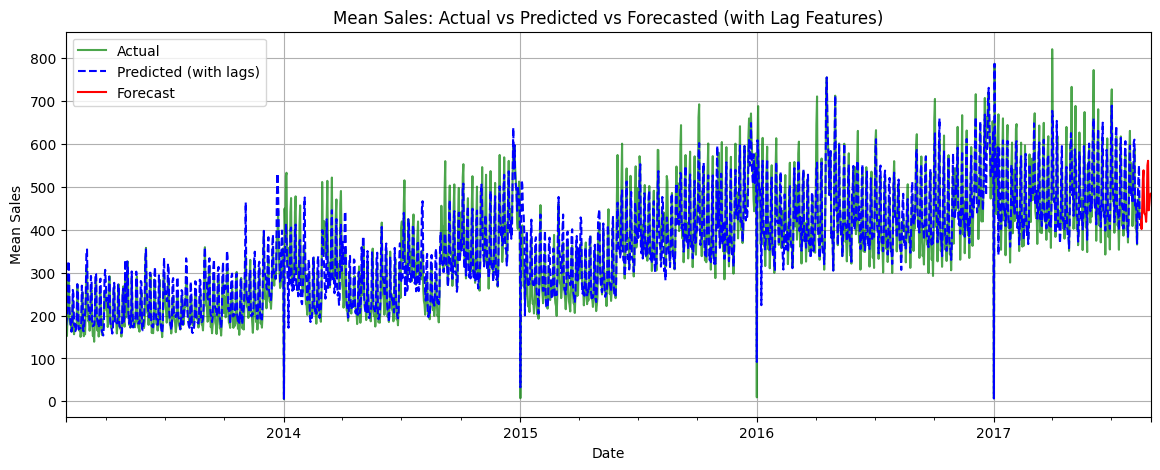

In [13]:
y_pred_stacked = y_pred.stack([2, 1], future_stack=True)
y_fore_stacked = y_fore.stack([2, 1], future_stack=True)

fig, ax = plt.subplots(figsize=(14, 5))
y_train.mean(axis=1).plot(ax=ax, label='Actual', color='green', alpha=0.7)
y_pred.mean(axis=1).plot(ax=ax, label='Predicted (with lags)', color='blue', linestyle='--')
y_fore.mean(axis=1).plot(ax=ax, label='Forecast', color='red')
ax.set_title('Mean Sales: Actual vs Predicted vs Forecasted (with Lag Features)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sales')
ax.legend()
plt.grid(True)
plt.show()
